<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/HomeWork/21062026_Clean_new_cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# ── Вкажіть шлях до вхідного файлу ──────────────────────────
# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

# ── Вкажіть шлях для збереження чистого файлу ───────────────
# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'cafe_sales_clean_clean_v2.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [ ]:
# Завантаження датасету
df_original = pd.read_csv(FILE_IN)
df = df_original.copy() # ВАШ КОД ТУТ  (копія оригіналу),
# ВАШ КОД ТУТ
# Перші 10 рядків
print("Size:", "Rows", df.shape[0], "x", df.shape[1], "Columns")  #
df.head(10)
df.columns


Size: Rows 10000 x 8 Columns


Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [ ]:
# Загальна інформація про датафрейм
# ВАШ КОД ТУТ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [ ]:
# Описова статистика (для числових І текстових колонок)

# Підказка: є параметр include='all'
# ВАШ КОД ТУТ

df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1
*(Запишіть тут що ви помітили — підозрілі значення, неправильні типи, тощо)*

- ...за рахунок некоректних данних викривлюється статистика,вони випадають із статистики
- ...типи данних не визначені правильно за рахунок некоректних значень
- ...є невідомі значення та значення які не ввійдуть до обчислень

## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [ ]:
# Знайти дублікати
n_dupes = df.duplicated().sum()
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати - немає що видаляти, дублікатів не знайдено
# ВАШ КОД ТУТ

print(f'Рядків після видалення: {len(df)}')

Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [ ]:

# 0.1 пошук варіантів брудних значень (з брудними значеннями загальгий відсоток  пропусків був 8,53%)
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", "NONE", "NULL"]

for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
            'Payment Method', 'Location', 'Transaction Date']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")

# ВАШ КОД ТУТ
# Крок 1: замінити 'брудні' значення на NaN
for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']:
    mask = df[col].astype(str).str.upper().isin(dirty)
    df.loc[mask, col] = np.nan


# Крок 2: порахувати пропуски
#missing_count = df.isnull().sum()
#missing_pct   = (missing_count/len(df)*100).round(2)   # ВАШ КОД ТУТ  (у відсотках від загальної кількості рядків)

#missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})


# Крок 3: загальний % пропусків
#total_pct = (missing_count.sum()/df.size * 100)
#total_pct_all = (missing_count.sum().sum()/df.size * 100)    # ВАШ КОД ТУТ
#print(f'\nЗагальний % пропусків: {total_pct:.2f}%')

'Transaction ID: брудних=0, NaN=0'

'Item: брудних=636, NaN=333'

'Quantity: брудних=341, NaN=138'

'Price Per Unit: брудних=354, NaN=179'

'Total Spent: брудних=329, NaN=173'

'Payment Method: брудних=599, NaN=2579'

'Location: брудних=696, NaN=3265'

'Transaction Date: брудних=301, NaN=159'

In [ ]:
# ВАШ КОД ТУТ
# Крок 1: замінити 'брудні' значення на NaN
for col in ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']:
    mask = df[col].astype(str).str.upper().isin(dirty)
    df.loc[mask, col] = np.nan

In [ ]:
# Крок 2: порахувати пропуски
missing_count = df.isnull().sum()
missing_pct   = (missing_count/len(df)*100).round(2)
# ВАШ КОД ТУТ  (у відсотках від загальної кількості рядків)

missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})
print(missing_df)


                  Пропусків      %
Transaction ID            0   0.00
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60


In [ ]:
# 3 основні групи з пропусками
missing_df.sort_values(by='%', ascending=False)


,Пропусків,%
Location,3961,39.61
Payment Method,3178,31.78
Item,969,9.69
Price Per Unit,533,5.33
Total Spent,502,5.02
Quantity,479,4.79
Transaction Date,460,4.60
Transaction ID,0,0.00


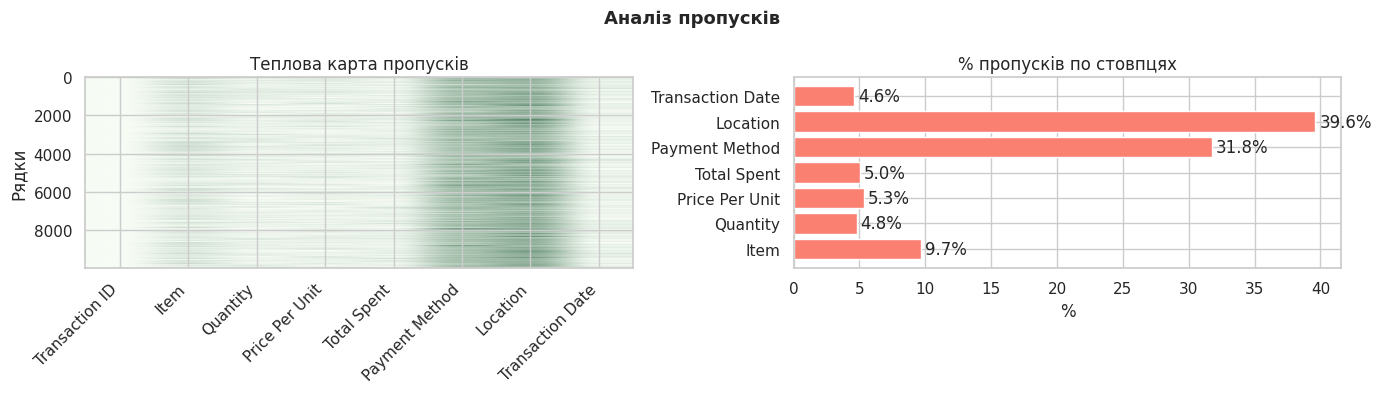

In [ ]:
# Крок 4: візуалізація пропусків

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Аналіз пропусків', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
axes[0].imshow(df.isnull(), aspect='auto', cmap='Greens')
axes[0].set_title('Теплова карта пропусків')
axes[0].set_xticks(range(len(df.columns)))
axes[0].set_xticklabels(df.columns, rotation=45, ha='right')
axes[0].set_ylabel('Рядки')

# Графік 2: Horizontal bar chart — % пропусків по колонках
missing_pct_filtered = missing_df[missing_df['Пропусків'] > 0]['%']
axes[1].barh(missing_pct_filtered.index, missing_pct_filtered.values, color='salmon')
axes[1].set_title('% пропусків по стовпцях')
axes[1].set_xlabel('%')
for i, v in enumerate(missing_pct_filtered.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [ ]:
# Крок 1: прибрати пробіли з назв
df.columns = df.columns.str.strip()

# Крок 2: перейменувати
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print('Нові назви колонок:', list(df.columns))
#print('Нові назви колонок:', list(df.columns))

Нові назви колонок: ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [ ]:
#до кожнох ціни список значень, формат ключ = списку якщо значення 1 береш, якщо більше береш рандомно.
# transaction_id: видалити рядки де NaN
before = len(df)
# ВАШ КОД ТУТ
print(f'Видалено рядків без transaction_id: {before - len(df)}')


# payment_method: заповнити 'Unknown'
df['payment_method'].fillna('Unknown', inplace=True)

# location: заповнити 'Unknown'
df['location'].fillna('Unknown', inplace=True)

# item: зберігаємо моду
mode_item = df['item'].mode()[0]
#print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')


Видалено рядків без transaction_id: 0


In [ ]:
df.location.unique()
df.payment_method.unique()

array(['Credit Card', 'Cash', 'Unknown', 'Digital Wallet'], dtype=object)

In [ ]:
df.location.unique()

array(['Takeaway', 'In-store', 'Unknown'], dtype=object)

## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [ ]:

# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)

df['quantity']         = pd.to_numeric(df['quantity'], errors='coerce')
df['price_per_unit']   = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['total_spent']      = pd.to_numeric(df['total_spent'], errors='coerce')
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

print('Типи після конвертації:')
print(df.dtypes)

Типи після конвертації:
transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object


In [ ]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
# ВАШ КОД ТУТ
item_price = df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
print(item_price)
# Зворотний словник: ціна → товар
# ВАШ КОД ТУТ
price_item = {}
for key, value in item_price.items():
    if value not in price_item.keys():
        price_item.setdefault(value, []) # значення в ключ, ключ в значення
        price_item[value].append(key)#додаємо
        print(key, value)
    else:
        price_item[value].append(key)
        print(key, value)
# Підказка: {round(v, 2): k for k, v in ITEM_PRICE.items()}

#print(f'Словник побудовано: {len(item_price)} товарів')
#print(pd.Series(item_price).sort_index())

{'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}
Cake 3.0
Coffee 2.0
Cookie 1.0
Juice 3.0
Salad 5.0
Sandwich 4.0
Smoothie 4.0
Tea 1.5


In [ ]:
import numpy as np
RANDOM_STATY = 42
np.random.default_rng(RANDOM_STATY)

price = 5
rnd_item = np.random.choice(price_item[price])
print(rnd_item)
print(price)

Salad
5


In [ ]:
df[df["item"].isna() & df["price_per_unit"].isna()].shape[0] # перевірка на 2 значення для розуміння кількісті відносно заг кількості

54

In [ ]:
df[df["item"].isna() & df["price_per_unit"].isna()& df["quantity"].isna()].shape[0] # перевірка на 3 значення відносно заг кількості

3

In [ ]:
df[df["item"].isna() & df["price_per_unit"].isna()].index[1]

np.int64(151)

In [ ]:
# Ситуація 1: item = NaN, price є → знаходимо item по ціні
#mask1 = df[df["item"].isna() & df["price_per_unit"].notna()]
#idx_situation1 = df.index[mask1]
#print(idx_situation1)
# ВАШ КОД ТУТ
#df.loc[mask1, 'item'] = df.loc[mask1, 'price_per_unit'].apply(
    #lambda price: np.random.choice(price_item[price]))
# Підказка: .round(2).map(PRICE_ITEM)
#print(f'Ситуація 1 (є price → item): {mask1.sum()} рядків')

# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
#mask2 = # ВАШ КОД ТУТ  (item notna AND price isna)
#df.loc[mask2, 'price_per_unit'] = # ВАШ КОД ТУТ
# Підказка: .map(ITEM_PRICE)
#print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')

# Ситуація 3:
# Ситуація 3: item і price = NaN, але total_spent і quantity відомі
#mask3 = df["item"].isna() & df["price_per_unit"].isna() & df["total_spent"].notna() & df["quantity"].notna()
#print("cbn  3", mask3.sum())
#df.loc[mask3, 'item'] =
#обидва NaN → item = мода, price = по item
#mask3 = # ВАШ КОД ТУТ  (item isna AND price isna)
#mode_item = df['item'].mode()[0]   # рахуємо після заповнення ситуацій 1 і 2
#df.loc[mask3, 'item']           = mode_item
#df.loc[mask3, 'price_per_unit'] = # ВАШ КОД ТУТ  (ITEM_PRICE.get(mode_item))
#print(f'Ситуація 3 (обидва NaN → мода "{mode_item}"): {mask3.sum()} рядків')

#print(f'\nNaN у item:           {df["item"].isna().sum()}')
#print(f'NaN у price_per_unit: {df["price_per_unit"].isna().sum()}')

In [ ]:
# Ситуація 1: item = NaN, price є → знаходимо item по ціні
mask1 = df["item"].isna() & df["price_per_unit"].notna()

# заповнення
df.loc[mask1, "item"] = df.loc[mask1, "price_per_unit"].apply(
    lambda price: np.random.choice(price_item[price]))

df["item"].isna().sum()

np.int64(54)

In [ ]:
# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
mask2 = df["item"].notna() & df['price_per_unit'].isna()
df.loc[mask2, 'price_per_unit'] = df.loc[mask2, 'item'].map(item_price)

df['price_per_unit'].isna().sum()
# Підказка: .map(ITEM_PRICE)
#print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')

np.int64(54)

In [ ]:
print("Залишилось NaN в item:", df["item"].isna().sum())
print("Залишилось NaN в price_per_unit:", df["price_per_unit"].isna().sum())

Залишилось NaN в item: 54
Залишилось NaN в price_per_unit: 54


In [ ]:
# Заповнення quantity
# Варіант А: є price і total_spent → qty = total / price
mask_qty = df["quantity"].isna() & df["price_per_unit"].notna() # ВАШ КОД ТУТ  (quantity isna AND price notna AND total notna)
df.loc[mask_qty, 'quantity'] = (df.loc[mask_qty, "total_spent"] / df.loc[mask_qty, "price_per_unit"]).round(2)# ВАШ КОД ТУТ
# Підказка: (total_spent / price_per_unit).round()
print(f'quantity відновлено через total/price_pre_unit: {mask_qty.sum()} рядків')

quantity відновлено через total/price_pre_unit: 476 рядків


In [ ]:
# Ситуація 3: item і price = NaN, але total_spent і quantity відомі
mask3 = df["item"].isna() & df["price_per_unit"].isna() & df["total_spent"].notna() & df["quantity"].notna()
print(mask3.sum())
df.loc[mask3, "price_per_unit"] = (df.loc[mask3, "total_spent"] / df.loc[mask3, "quantity"]).round(2)

df.loc[mask3, "item"] = df.loc[mask3, "price_per_unit"].apply(
    lambda price: np.random.choice(price_item[price]) if price in price_item else np.nan
)

print(f'Залишилось NaN в item: {df["item"].isna().sum()}')
print(f'Залишилось NaN в price_per_unit: {df["price_per_unit"].isna().sum()}')

48
Залишилось NaN в item: 6
Залишилось NaN в price_per_unit: 6


In [ ]:
# total_spent NaN, є new quantity і price_per_unit
mask_total = df["total_spent"].isna() & df["quantity"].notna() & df["price_per_unit"].notna()
df.loc[mask_total, "total_spent"] = df.loc[mask_total, "quantity"] * df.loc[mask_total, "price_per_unit"]

# price_per_unit NaN, є new total_spent і new quantity
mask_price = df["price_per_unit"].isna() & df["total_spent"].notna() & df["quantity"].notna()
df.loc[mask_price, "price_per_unit"] = (df.loc[mask_price, "total_spent"] / df.loc[mask_price, "quantity"]).round(2)

In [ ]:
print(df.isna().sum())

transaction_id        0
item                  6
quantity             23
price_per_unit        6
total_spent          23
payment_method        0
location              0
transaction_date    460
dtype: int64


In [ ]:
#df.loc[mask_total_spent]

In [ ]:
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 26


In [ ]:
print(df.isna().sum())

transaction_id        0
item                  6
quantity             23
price_per_unit        6
total_spent          23
payment_method        0
location              0
transaction_date    460
dtype: int64


In [ ]:
df.item.isna().sum()

np.int64(6)

In [ ]:
diff = (df["quantity"] * df["price_per_unit"] - df["total_spent"]).abs()
print("Максимальна розбіжність:", diff.max())
print("Кількість рядків з розбіжністю > 0.01:", (diff > 0.01).sum())

Максимальна розбіжність: 0.0
Кількість рядків з розбіжністю > 0.01: 0


In [ ]:
test_prices = df.loc[df["item"].isna(), "price_per_unit"]
print(test_prices.unique())
print(list(price_item.keys()))

[nan]
[3.0, 2.0, 1.0, 5.0, 4.0, 1.5]


In [ ]:
mask_diff = (df["quantity"] * df["price_per_unit"] - df["total_spent"]).abs() > 0.01
df.loc[mask_diff, ["quantity", "price_per_unit", "total_spent"]]


,quantity,price_per_unit,total_spent


In [ ]:
df.loc[df["item"].isna(), ["item", "price_per_unit", "total_spent", "quantity"]]

,item,price_per_unit,total_spent,quantity
1761,NaN,NaN,NaN,4.0
2289,NaN,NaN,NaN,4.0
3779,NaN,NaN,25.0,NaN
4152,NaN,NaN,NaN,2.0
7597,NaN,NaN,9.0,NaN
9819,NaN,NaN,20.0,NaN


In [ ]:
df.loc[df["quantity"].isna(), ["item", "price_per_unit", "total_spent", "quantity"]]

,item,price_per_unit,total_spent,quantity
236,Salad,5.0,NaN,NaN
278,Juice,3.0,NaN,NaN
641,Juice,3.0,NaN,NaN
738,Sandwich,4.0,NaN,NaN
2796,Cake,3.0,NaN,NaN
3203,Smoothie,4.0,NaN,NaN
3224,Coffee,2.0,NaN,NaN
3401,Tea,1.5,NaN,NaN
3779,NaN,NaN,25.0,NaN
4257,Coffee,2.0,NaN,NaN


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [ ]:
# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = # ВАШ КОД ТУТ  (qty × price, round(2))

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = # ВАШ КОД ТУТ
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

if n_mismatch > 0:
    # Крок 3: показати перші 5 розбіжностей
    print('\nПерші 5 (до виправлення):')
    print(df.loc[mask_mismatch,
                 ['item','quantity','price_per_unit','total_spent','_expected']].head())

    # Крок 4: ПЕРЕЗАПИСАТИ total_spent перерахованим значенням
    # ВАШ КОД ТУТ
    print(f'\n→ total_spent перезаписано для {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True)

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (df['total_spent'].round(2) !=
             (df['quantity'].astype(float) * df['price_per_unit']).round(2)).sum()
print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')

# Видалити рядки без дати
before = len(df)
# ВАШ КОД ТУТ
print(f'Видалено рядків без дати: {before - len(df)}')

SyntaxError: invalid syntax (3008245804.py, line 2)

# Для рядків де є item і price_per_unit, але немає quantity і total_spent
# Заповнюємо quantity медіаною (типова кількість покупки)
mask_qty_only = df["item"].notna() & df["price_per_unit"].notna() & df["quantity"].isna()
median_qty = df["quantity"].median()
df.loc[mask_qty_only, "quantity"] = median_qty
df.loc[mask_qty_only, "total_spent"] = df.loc[mask_qty_only, "quantity"] * df.loc[mask_qty_only, "price_per_unit"]

print(f'Заповнено quantity медіаною ({median_qty}) для {mask_qty_only.sum()} рядків')

# Перевірка решти




# --- Фінальне очищення: видалення всіх рядків з пропусками ---
# Рішення: рядки без коректних item/price/quantity/total_spent неможливо
# повністю довести до достовірного стану навіть після відновлення через
# математичні залежності (Ситуації 1-3), тому видаляємо їх остаточно.
# Окремо видаляємо рядки без transaction_date, оскільки дата важлива
# для подальшого аналізу (часові тренди, сезонність тощо) і не може
# бути логічно відновлена з інших полів.

# Маска для всіх "проблемних" рядків
mask_drop = (
    df["item"].isna() |
    df["quantity"].isna() |
    df["price_per_unit"].isna() |
    df["total_spent"].isna() |
    df["transaction_date"].isna()
)

# Зберігаємо індекси та самі видалені рядки для аудиту
dropped_indices = df.index[mask_drop].tolist()
dropped_rows = df.loc[mask_drop].copy()

print(f'Рядків для видалення: {len(dropped_indices)}')
print(f'Це {len(dropped_indices) / len(df) * 100:.2f}% від датасету')

# Видаляємо рядки з основного датафрейму
df = df.drop(index=dropped_indices).reset_index(drop=True)

print(f'\nЗалишилось рядків: {len(df_clean)}')
print(f'Перевірка пропусків після видалення:\n{df_clean.isna().sum()}')

# --- Збереження результатів у CSV ---
df_clean.to_csv("cleaned_transactions.csv", index=False)
dropped_rows.to_csv("dropped_rows_log.csv", index=True)

print('\nФайли збережено: cleaned_transactions.csv, dropped_rows_log.csv')
Опис для документації проєкту (як зазвичай пишуть аналітики у звіті/README):

Очищення пропущених значень. Після відновлення частини даних через логічні залежності (ціна↔товар, кількість↔сума↔ціна), залишкові рядки з непокритими пропусками — 6 рядків без item/price_per_unit, 23 рядки без quantity/total_spent, та 460 рядків без transaction_date — було видалено з датасету, оскільки відсутність дати критична для аналізу часових трендів, а відсутність товару/ціни/кількості унеможливлює достовірний розрахунок виручки. Загалом видалено N рядків (X% датасету). Видалені рядки збережені окремо у файлі dropped_rows_log.csv для аудиту. Очищені дані збережено у cleaned_transactions.csv.

Якщо хочеш, я можу запустити цей код у себе (через bash_tool), якщо ти завантажиш файл з даними — або просто скопіюй цей код у свій ноутбук і виконай там, щоб N та X% підрахувались для твого реального датасету.

## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [ ]:
for col in ['item', 'payment_method', 'location']:
    df[col] = # ВАШ КОД ТУТ

print('Унікальні payment_method:', sorted(df['payment_method'].unique()))
print('Унікальні location:',       sorted(df['location'].unique()))

## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [ ]:
df['year']       = # ВАШ КОД ТУТ
df['month']      = # ВАШ КОД ТУТ
df['month_name'] = # ВАШ КОД ТУТ
df['weekday']    = # ВАШ КОД ТУТ
df['week']       = df['transaction_date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = # ВАШ КОД ТУТ

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['total_spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head()

In [ ]:
# Зберегти чистий файл
df_tableau = df.copy()
df_tableau['transaction_date'] = df_tableau['transaction_date'].dt.strftime('%Y-%m-%d')
df_tableau['is_weekend'] = df_tableau['is_weekend'].map({True: 'Yes', False: 'No'})
df_tableau.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [ ]:
# Топ-5 за кількістю
top_qty = # ВАШ КОД ТУТ

# Топ-5 за виторгом
top_rev = # ВАШ КОД ТУТ

print('Топ-5 за кількістю:')
print(top_qty.to_string())
print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
# ВАШ КОД ТУТ
axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
# ВАШ КОД ТУТ
axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1
*(Що помітили? Чи збігаються топи за кількістю та виторгом?)*

- ...

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [ ]:
rev_pay = # ВАШ КОД ТУТ
rev_loc = # ВАШ КОД ТУТ

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')

# Pie chart — payment_method
# Підказка: axes[0].pie(rev_pay, labels=rev_pay.index, autopct='%1.1f%%', startangle=90, ...)
# ВАШ КОД ТУТ
axes[0].set_title('Виторг по способу оплати')

# Bar chart — location
# ВАШ КОД ТУТ
axes[1].set_title('Виторг по локації')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.2

- Який спосіб оплати домінує: ___
- In-store чи Takeaway більше: ___

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [ ]:
# Щоденний виторг
daily_rev = # ВАШ КОД ТУТ

# Щомісячний виторг
monthly_rev = # ВАШ КОД ТУТ

# По днях тижня (середнє)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_dow = # ВАШ КОД ТУТ

print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')

# Графік 1: щоденний лінійний
# ВАШ КОД ТУТ
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')

# Графік 2: щомісячний бар
# Підказка: зробіть колонку label = перші 3 літери місяця + рік
# ВАШ КОД ТУТ
axes[1].set_title('Щомісячний виторг')

# Графік 3: по днях тижня (вихідні = червоні, будні = сині)
colors_dow = ['#E74C3C' if d in ['Saturday','Sunday'] else '#3498DB' for d in avg_dow.index]
# ВАШ КОД ТУТ
axes[2].set_title('Середній виторг по днях тижня')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()

# Знайти місяць з найнижчим виторгом
worst_month = # ВАШ КОД ТУТ
print(f'Місяць з найнижчим виторгом: {worst_month}')

### ✏️ Висновок до Task 3.3

- Найкращий день тижня: ___
- Найгірший місяць: ___
- Є сезонний тренд? ___

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
# Підказка: sns.boxplot(y=df['quantity'].astype(float), ax=axes[0], color='lightblue', ...)
# ВАШ КОД ТУТ
axes[0].set_title('Quantity')

# Boxplot для total_spent
# ВАШ КОД ТУТ
axes[1].set_title('Total Spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# Кількісний аналіз викидів методом IQR
Q1  = # ВАШ КОД ТУТ  (25-й перцентиль total_spent)
Q3  = # ВАШ КОД ТУТ  (75-й перцентиль)
IQR = # ВАШ КОД ТУТ

low  = # ВАШ КОД ТУТ  (нижня межа)
high = # ВАШ КОД ТУТ  (верхня межа)

n_outliers = # ВАШ КОД ТУТ  (кількість значень поза межами)

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')

### ✏️ Рішення щодо викидів
*(Напишіть своє рішення та обгрунтування)*

**Рішення:** залишити / видалити / кепувати (потрібне підкресліть)

**Обгрунтування:** ...

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

In [ ]:
corr_cols   = ['quantity', 'price_per_unit', 'total_spent']
corr_matrix = # ВАШ КОД ТУТ

print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
# Підказка: sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ...)
# ВАШ КОД ТУТ

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|----------|------|-----------|
| total_spent ↔ quantity | ___ | ___ | ___ |
| total_spent ↔ price_per_unit | ___ | ___ | ___ |
| quantity ↔ price_per_unit | ___ | ___ | ___ |

---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [ ]:
# Зберіть всі ключові метрики і надрукуйте підсумковий звіт

top_item_rev  = # ВАШ КОД ТУТ  (найприбутковіший товар)
top_item_qty  = # ВАШ КОД ТУТ  (найпопулярніший за кількістю)
top_pay       = # ВАШ КОД ТУТ  (домінуючий спосіб оплати)
top_loc       = # ВАШ КОД ТУТ  (топ локація)
total_revenue = # ВАШ КОД ТУТ
avg_check     = # ВАШ КОД ТУТ

print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)

# Напишіть свій звіт тут — власними словами!
# ВАШ КОД ТУТ

## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [ ] Завантажено і оглянуто датасет
- [ ] Знайдено і видалено дублікати
- [ ] Порахована і візуалізована кількість пропусків

**Частина 2**
- [ ] Перейменовано колонки
- [ ] Замінено ERROR/UNKNOWN на NaN
- [ ] Заповнено пропуски payment_method і location
- [ ] Конвертовано типи даних
- [ ] Побудовано словник ITEM_PRICE з даних
- [ ] Оброблено три ситуації item/price
- [ ] Відновлено quantity (через total/price або медіана по товару)
- [ ] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [ ] Стандартизовано текст
- [ ] Додано часові ознаки
- [ ] Збережено FILE_OUT

**Частина 3**
- [ ] Task 3.1: топ товари — два бар-чарти
- [ ] Task 3.2: оплата і локація — pie + bar
- [ ] Task 3.3: часові тренди — 3 графіки
- [ ] Task 3.4: boxplot + IQR аналіз
- [ ] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [ ] Підсумковий звіт з конкретними числами
- [ ] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**